In [1]:
import os
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt

Elaborazione tipologia 'CNN1D_RNN': trovati 10 file.
Elaborazione tipologia 'CNN2D_RNN': trovati 10 file.
Elaborazione tipologia 'CNN1D': trovati 10 file.
Elaborazione tipologia 'CNN2D': trovati 10 file.

--- RIEPILOGO STATISTICO (Media ± Dev.Std tra i seed) ---

Metrica: MAE
  - CNN1D_RNN: 0.0182 ± 0.000325
  - CNN2D_RNN: 0.0203 ± 0.000582
  - CNN1D: 0.0184 ± 0.000658
  - CNN2D: 0.0212 ± 0.001102

Metrica: ME
  - CNN1D_RNN: 0.0001 ± 0.002112
  - CNN2D_RNN: 0.0017 ± 0.002520
  - CNN1D: 0.0002 ± 0.001784
  - CNN2D: -0.0008 ± 0.003190

Metrica: MAPE
  - CNN1D_RNN: 5.47% ± 0.14%
  - CNN2D_RNN: 6.10% ± 0.18%
  - CNN1D: 5.52% ± 0.25%
  - CNN2D: 6.27% ± 0.34%

Metrica: MSE
  - CNN1D_RNN: 0.0006 ± 0.000025
  - CNN2D_RNN: 0.0008 ± 0.000079
  - CNN1D: 0.0007 ± 0.000055
  - CNN2D: 0.0009 ± 0.000145

Metrica: RMSE
  - CNN1D_RNN: 0.0254 ± 0.000502
  - CNN2D_RNN: 0.0282 ± 0.001368
  - CNN1D: 0.0256 ± 0.001039
  - CNN2D: 0.0298 ± 0.002375

Metrica: R2
  - CNN1D_RNN: 0.9769 ± 0.000959
  - CNN2D_RNN: 

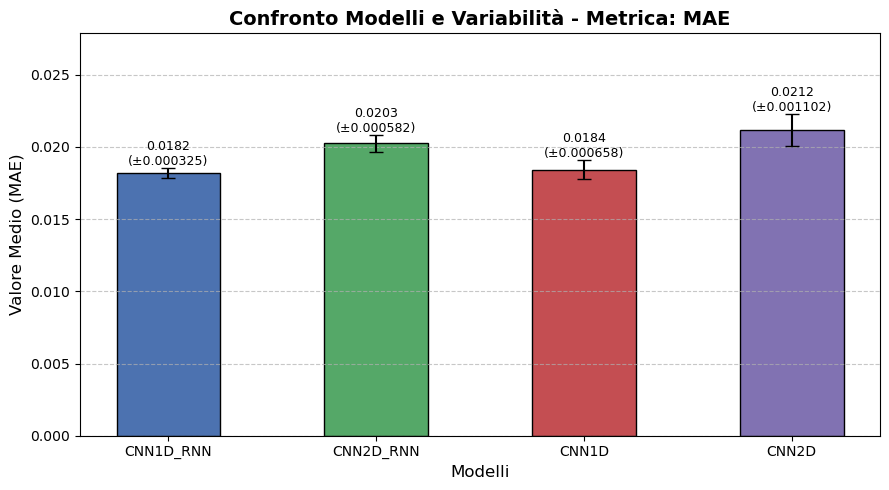

Grafico salvato: MedieSeeds/Confronto_ME.png


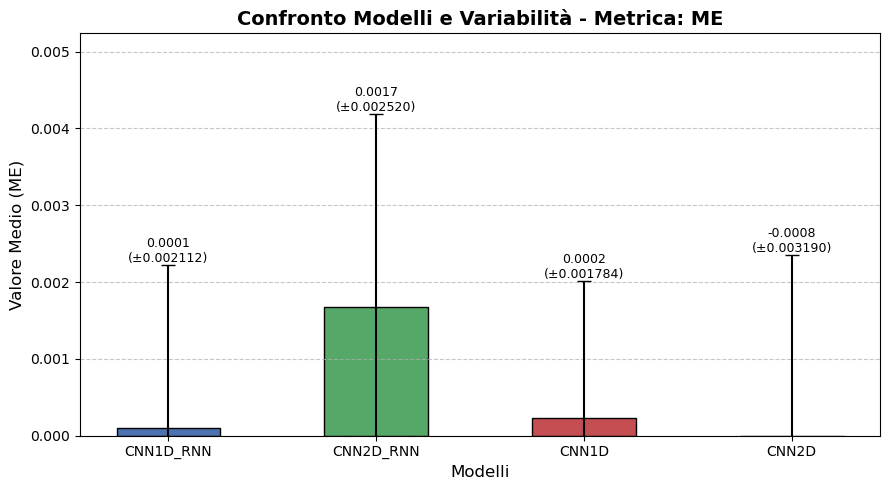

Grafico salvato: MedieSeeds/Confronto_MAPE.png


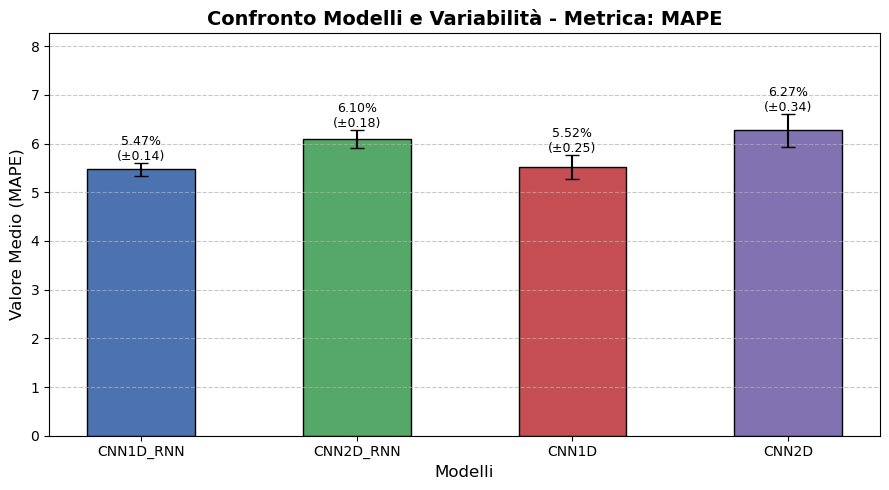

Grafico salvato: MedieSeeds/Confronto_MSE.png


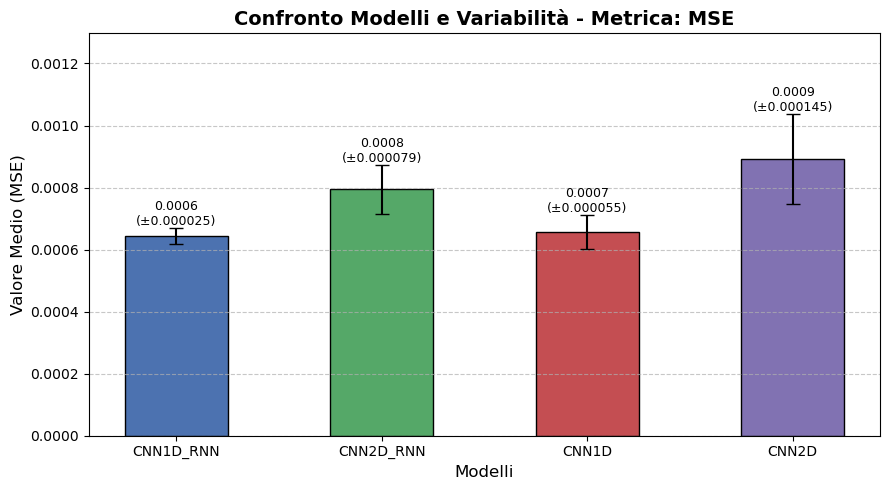

Grafico salvato: MedieSeeds/Confronto_RMSE.png


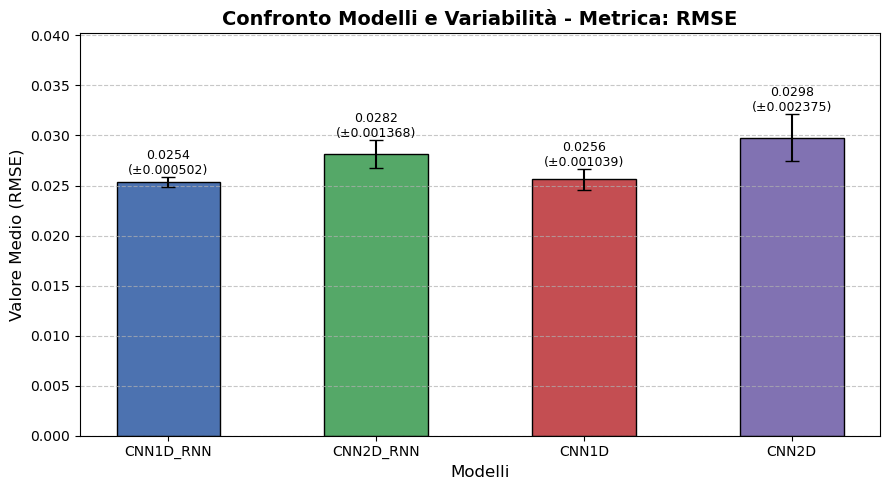

Grafico salvato: MedieSeeds/Confronto_R2.png


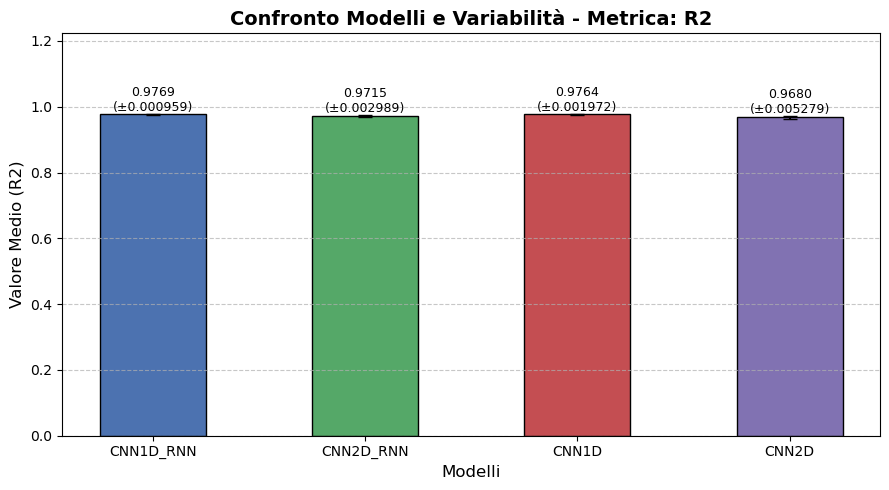


Elaborazione completata con successo!


In [2]:
# 1. Creazione della cartella di destinazione per i grafici
output_directory = "MedieSeeds"
os.makedirs(output_directory, exist_ok=True)

# 2. Definizione delle tipologie di modelli e ricerca file
model_types = ["CNN1D_RNN", "CNN2D_RNN", "CNN1D", "CNN2D"]
all_csv_files = glob.glob("**/*.csv", recursive=True)

# Dizionari per memorizzare medie e deviazioni standard
metrics_stats_by_model = {}

for model_type in model_types:
    file_pattern = re.compile(rf".*{model_type}ResultsForMicro_(\d+)\.csv$", re.IGNORECASE)
    seed_files = [file_path for file_path in all_csv_files if file_pattern.search(file_path)]
            
    print(f"Elaborazione tipologia '{model_type}': trovati {len(seed_files)} file.")
    
    if not seed_files:
        continue
        
    best_rows_per_model = []
    
    for seed_file in seed_files:
        try:
            seed_df = pd.read_csv(seed_file)
            
            if 'MAE_test' in seed_df.columns:
                seed_df = seed_df.sort_values(by='MAE_test', ascending=True)
                best_row = seed_df.iloc[0].copy()
                best_rows_per_model.append(best_row)
                
        except Exception as e:
            print(f"Errore nella lettura di {seed_file}: {e}")
            
    if not best_rows_per_model:
        continue
        
    best_models_df = pd.DataFrame(best_rows_per_model)
    
    test_columns = [col for col in best_models_df.columns if col.endswith('_test')]
    
    for col in test_columns:
        if col.lower() == 'mape_test':
            cleaned_values = best_models_df[col].astype(str).str.replace('%', '', regex=False).str.strip()
            best_models_df[col] = pd.to_numeric(cleaned_values, errors='coerce')
        elif col.lower() == 'mae_test':
            pass
            
    metrics_mean_values = best_models_df[test_columns].mean(numeric_only=True)
    metrics_std_values = best_models_df[test_columns].std(numeric_only=True)
    
    for col in test_columns:
        if col in metrics_mean_values.index:
            if col not in metrics_stats_by_model:
                metrics_stats_by_model[col] = {}
            metrics_stats_by_model[col][model_type] = {
                'mean': metrics_mean_values[col],
                'std': metrics_std_values[col] if pd.notna(metrics_std_values[col]) else 0.0
            }

# Stampa riepilogo testuale
print("\n--- RIEPILOGO STATISTICO (Media ± Dev.Std tra i seed) ---")
for metric_col, model_dict in metrics_stats_by_model.items():
    clean_metric_name = metric_col.replace('_test', '')
    print(f"\nMetrica: {clean_metric_name}")
    for m_type, stats in model_dict.items():
        if clean_metric_name.lower() == 'mape':
            print(f"  - {m_type}: {stats['mean']:.2f}% ± {stats['std']:.2f}%")
        else:
            print(f"  - {m_type}: {stats['mean']:.4f} ± {stats['std']:.6f}")

# Palette di colori distinti per ogni tipologia di modello
model_colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

# 7. Genera un grafico (istogramma con barre d'errore) per ogni metrica
for metric_col, model_values_dict in metrics_stats_by_model.items():
    clean_metric_name = metric_col.replace('_test', '')
    
    plt.figure(figsize=(9, 5))
    
    available_models = [m for m in model_types if m in model_values_dict]
    mean_scores = [model_values_dict[m]['mean'] for m in available_models]
    std_scores = [model_values_dict[m]['std'] for m in available_models]
    
    # Seleziona i colori in base al numero di modelli disponibili
    current_colors = model_colors[:len(available_models)]
    
    bars = plt.bar(available_models, mean_scores, yerr=std_scores, capsize=5, edgecolor='black', color=current_colors, width=0.5)
    
    # Calcolo dinamico del limite Y per evitare sovrapposizioni col titolo
    if mean_scores:
        max_top = max([m + s for m, s in zip(mean_scores, std_scores)])
        plt.ylim(0, max_top * 1.25 if max_top > 0 else 1.0)
    
    plt.title(f'Confronto Modelli e Variabilità - Metrica: {clean_metric_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Modelli', fontsize=12)
    plt.ylabel(f'Valore Medio ({clean_metric_name})', fontsize=12)
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Mostra i valori sopra le barre con la formattazione richiesta
    for bar, std_val in zip(bars, std_scores):
        bar_height = bar.get_height()
        if pd.notna(bar_height):
            if clean_metric_name.lower() == 'mape':
                text_label = f'{bar_height:.2f}%\n(±{std_val:.2f})'
            else:
                text_label = f'{bar_height:.4f}\n(±{std_val:.6f})'
                
            plt.text(bar.get_x() + bar.get_width()/2., bar_height + std_val, text_label,
                     ha='center', va='bottom', fontsize=9)
            
    plt.tight_layout()
    
    output_image_path = os.path.join(output_directory, f"Confronto_{clean_metric_name}.png")
    plt.savefig(output_image_path, dpi=300)
    print(f"Grafico salvato: {output_image_path}")
    
    plt.show()

print("\nElaborazione completata con successo!")